In [112]:
# load datasets
import pandas as pd
import matplotlib.pylab as plt
import numpy as np

df_sales = pd.read_csv('Sales.csv', encoding='latin1')                      # Cleaned
df_customers = pd.read_csv('Customers.csv', encoding='latin1')              # Cleaned
df_products = pd.read_csv('Products.csv', encoding='latin1')                # Cleaned
df_stores = pd.read_csv('Stores.csv', encoding='latin1')                    # Cleaned
df_fx = pd.read_csv('Exchange_Rates.csv', encoding='latin1')

# Data consistency checks and cleaning
1. **Sales** dataframe
* Converted ```Order Date``` and ```Delivery Date``` to datetime data type
* The sales dataset contains **nine** columns. ```Delivery Date``` contains **49719** number of empty fields representing **79%** of the total columns
* Sales orders span from ```2016-01-01``` to ```2021-02-20```
- Derrived columns
* Created ```order_month``` and ```order_year``` columns for better time series analysis
2. **Products** dataframe
* The products dataframe contains 2517 rows and 10 columns. This dataset does not contain any null/empty or duplicate values
* Removed **$** symbol from ```Unit Cost USD``` and ```Unit Price USD```
* After analysing the rest of the table I discovered that ```Unit Cost USD``` and ```Unit Price USD``` are object type. 
* Converted ```Unit Cost USD``` and ```Unit Price USD``` to integer float
3. Customers dataframe
* This dataset contains **15266** rows and **10** columns
* Found **10** empty values in the ```State Code``` column
* Converted customer birthday to datetime data type
4. Stores
* This dataset contains **67** rows and **5** columns 
* After the data checks it was found that one shop is missing ```Square Meters``` meassurements. No cleaning or data replacement was implemented in this column
* No duplicates were found


In [113]:
df_sales['Order Date'] = pd.to_datetime(df_sales['Order Date'])
df_sales['Delivery Date'] = pd.to_datetime(df_sales['Delivery Date'])
null_value_delivery_date = df_sales['Delivery Date'].isnull().mean() * 100

df_sales['order_month'] = df_sales['Order Date'].dt.to_period('M')
df_sales['order_year'] = df_sales['Order Date'].dt.year
df_sales.head()

,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code,order_month,order_year
0,366000,1,2016-01-01,NaT,265598,10,1304,1,CAD,2016-01,2016
1,366001,1,2016-01-01,2016-01-13,1269051,0,1048,2,USD,2016-01,2016
2,366001,2,2016-01-01,2016-01-13,1269051,0,2007,1,USD,2016-01,2016
3,366002,1,2016-01-01,2016-01-12,266019,0,1106,7,CAD,2016-01,2016
4,366002,2,2016-01-01,2016-01-12,266019,0,373,1,CAD,2016-01,2016


In [114]:
for col in ['Unit Cost USD', 'Unit Price USD']:
    df_products[col] = (
        df_products[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
    )
    
for col in ['Unit Cost USD', 'Unit Price USD']:
    df_products[col] = pd.to_numeric(df_products[col], errors='coerce')

df_products.head()

,ProductKey,Product Name,Brand,Color,Unit Cost USD,Unit Price USD,SubcategoryKey,Subcategory,CategoryKey,Category
0,1,Contoso 512MB MP3 Player E51 Silver,Contoso,Silver,6.62,12.99,101,MP4&MP3,1,Audio
1,2,Contoso 512MB MP3 Player E51 Blue,Contoso,Blue,6.62,12.99,101,MP4&MP3,1,Audio
2,3,Contoso 1G MP3 Player E100 White,Contoso,White,7.40,14.52,101,MP4&MP3,1,Audio
3,4,Contoso 2G MP3 Player E200 Silver,Contoso,Silver,11.00,21.57,101,MP4&MP3,1,Audio
4,5,Contoso 2G MP3 Player E200 Red,Contoso,Red,11.00,21.57,101,MP4&MP3,1,Audio


In [115]:
df_customers.head()
df_customers['Birthday'] = pd.to_datetime(df_customers['Birthday'])
df_customers.head()

,CustomerKey,Gender,Name,City,State Code,State,Zip Code,Country,Continent,Birthday
0,301,Female,Lilly Harding,WANDEARAH EAST,SA,South Australia,5523,Australia,Australia,1939-07-03
1,325,Female,Madison Hull,MOUNT BUDD,WA,Western Australia,6522,Australia,Australia,1979-09-27
2,554,Female,Claire Ferres,WINJALLOK,VIC,Victoria,3380,Australia,Australia,1947-05-26
3,786,Male,Jai Poltpalingada,MIDDLE RIVER,SA,South Australia,5223,Australia,Australia,1957-09-17
4,1042,Male,Aidan Pankhurst,TAWONGA SOUTH,VIC,Victoria,3698,Australia,Australia,1965-11-19


In [116]:
df_stores['Open Date'] = pd.to_datetime(df_stores['Open Date'])

In [117]:
# Joining products dataframe and sales
main_df = pd.merge(df_sales, df_products, how='left', on='ProductKey')


In [129]:
# del main_df['Currency Code']
# del main_df['SubcategoryKey']
# del main_df['CategoryKey']

main_df['Revenue'] = main_df['Quantity'] * main_df['Unit Price USD']
main_df['Profit'] = (main_df['Quantity'] * main_df['Unit Price USD']) - (main_df['Quantity'] * main_df['Unit Cost USD'])
# Cost per transaction
main_df['Cost'] = main_df['Quantity'] * main_df['Unit Cost USD']

# profit margin per product
main_df['Profit Margin'] = np.where(
    main_df['Revenue'] != 0,
    (main_df['Profit'] / main_df['Revenue']) * 100,
    0
)

main_df.head()


,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code,order_month,order_year,Product Name,Brand,Color,Unit Cost USD,Unit Price USD,Subcategory,Category,Revenue,Profit,Profit Margin,Cost
0,366000,1,2016-01-01,NaT,265598,10,1304,1,CAD,2016-01,2016,Contoso Lens Adapter M450 White,Contoso,White,31.27,68.00,Cameras & Camcorders Accessories,Cameras and camcorders,68.00,36.73,54.014706,31.27
1,366001,1,2016-01-01,2016-01-13,1269051,0,1048,2,USD,2016-01,2016,A. Datum SLR Camera X136 Silver,A. Datum,Silver,141.47,427.00,Digital SLR Cameras,Cameras and camcorders,854.00,571.06,66.868852,282.94
2,366001,2,2016-01-01,2016-01-13,1269051,0,2007,1,USD,2016-01,2016,Fabrikam Microwave 1.5CuFt X1100 Black,Fabrikam,Black,220.64,665.94,Microwaves,Home Appliances,665.94,445.30,66.867886,220.64
3,366002,1,2016-01-01,2016-01-12,266019,0,1106,7,CAD,2016-01,2016,Contoso SLR Camera M146 Orange,Contoso,Orange,148.08,322.00,Digital SLR Cameras,Cameras and camcorders,2254.00,1217.44,54.012422,1036.56
4,366002,2,2016-01-01,2016-01-12,266019,0,373,1,CAD,2016-01,2016,Adventure Works Laptop8.9 E0890 White,Adventure Works,White,166.20,326.00,Laptops,Computers,326.00,159.80,49.018405,166.20


<Figure size 600x400 with 0 Axes>

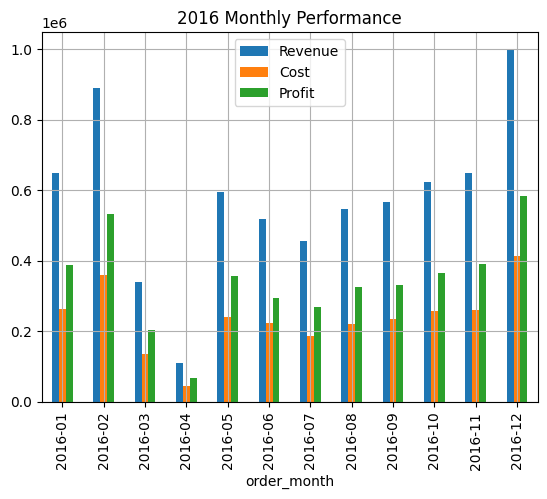

<Figure size 600x400 with 0 Axes>

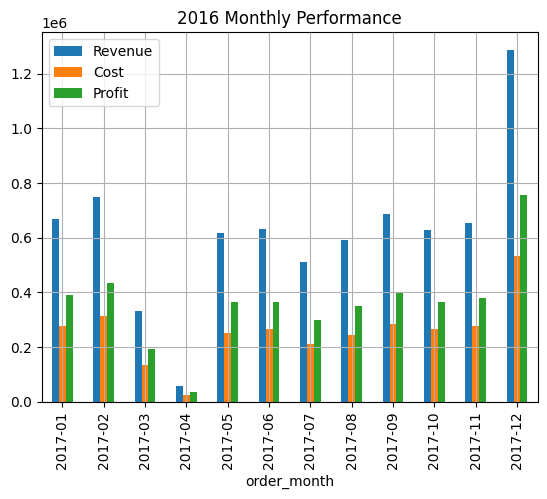

<Figure size 600x400 with 0 Axes>

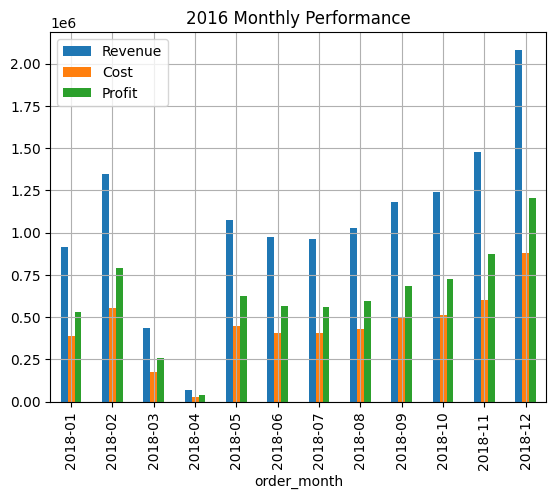

<Figure size 600x400 with 0 Axes>

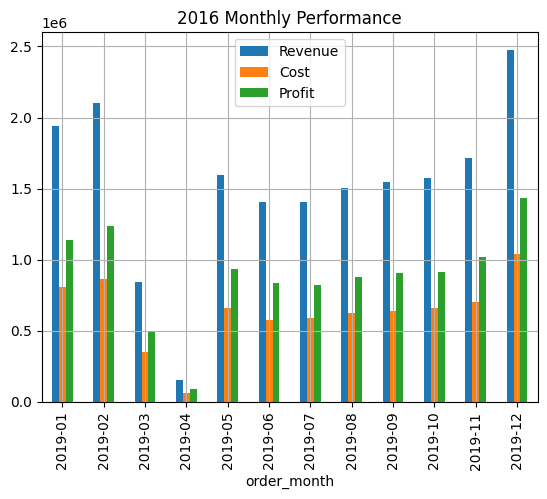

In [ ]:
# find out the main KPIs
from numerize import numerize
total_revenue = main_df['Revenue'].sum()
total_profit = main_df['Profit'].sum()
total_costs = main_df['Cost'].sum()
overall_profit_margin = (total_profit / total_revenue) * 100

total_volume = main_df['Quantity'].sum()


# year groups
year_groups = main_df.groupby('order_year')[['Revenue', 'Cost', 'Profit']].sum().reset_index()

# first year grouping
year_month = main_df.groupby(["order_year", "order_month"])[["Revenue", "Cost", "Profit"]].sum().reset_index()

# best profit grouping by revenue, costs and profit







def plot_month_years(year):
    plt.figure(figsize=(6, 4))
    df_2016 = year_month[year_month['order_year'] == year]

    df_2016.plot(
        x="order_month",
        y=["Revenue", "Cost", "Profit"],
        kind="bar"
    )

    plt.grid(True)
    plt.legend()
    plt.title("2016 Monthly Performance")

    plt.show()

